<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/set4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ STEP 0: SETUP ================
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Environment ready. Using device: cpu

================ STEP 1: DATA LOADING (FULL) ================
train.csv → (160000, 2)
test.csv → (160000, 2)
phiusiil.csv → (235795, 2)

================ STEP 2: LABEL DISTRIBUTION ================


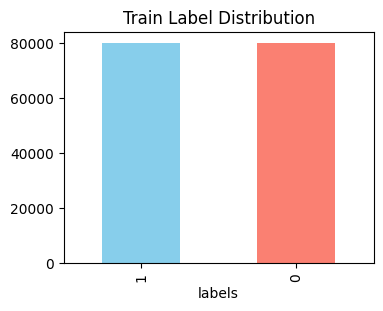

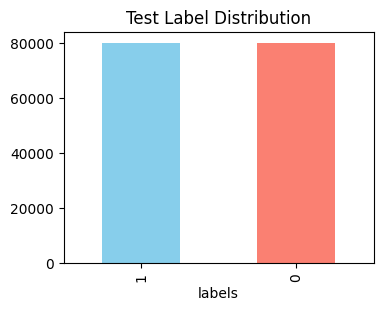

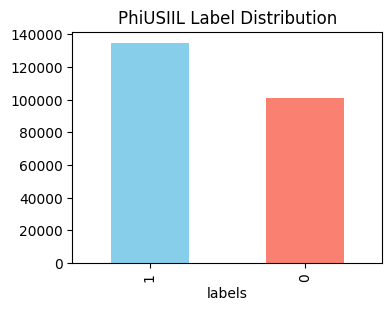


================ STEP 3: LEXICAL FEATURES ================

================ STEP 4: CHAR N-GRAM TF-IDF ================

================ STEP 5: FEATURE FUSION ================

================ STEP 6: ONLINE ML (LOGISTIC REGRESSION) ================

================ STEP 7: ANOMALY DETECTION (ISOLATION FOREST) ================


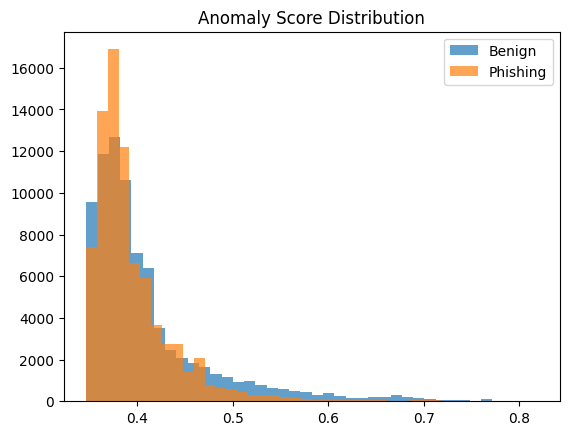


================ STEP 8: TINY TCN + ATTENTION (DEEP LEARNING) ================
Epoch 1 Loss: 0.37621242752075196
Epoch 2 Loss: 0.2771906586408615
Epoch 3 Loss: 0.24834726321697234

================ STEP 9: SCORE FUSION (HYBRID LOGIC) ================

================ STEP 10: EVALUATION ================

TEST SET RESULTS:
Accuracy: 0.9157 | Precision: 0.8993 | Recall: 0.9361 | F1: 0.9174
PR-AUC: 0.9686

PHIUSIIL (ZERO-DAY) RESULTS:
Accuracy: 0.7821 | Precision: 0.7241 | Recall: 1.0000 | F1: 0.8400
PR-AUC: 0.9383

================ STEP 11: COMPUTATIONAL EFFICIENCY ================
ML Inference Time/url: 0.000006s
DL Inference Time/url: 0.001757s
Model Complexity (Params): 18626

================ STEP 12: CONCEPT DRIFT DETECTION ================


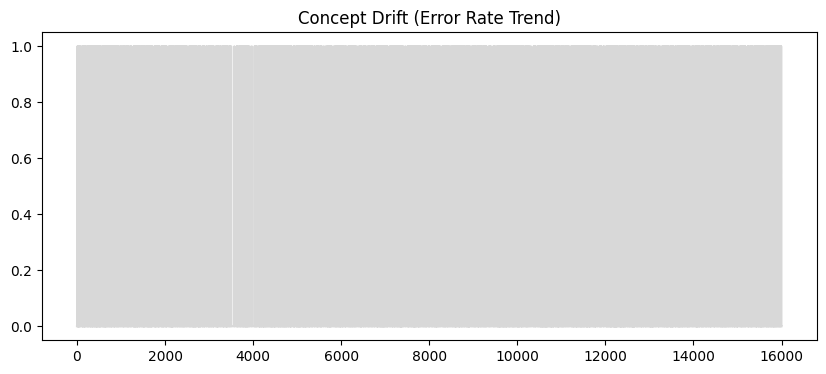


================ FULL HYBRID PIPELINE COMPLETED ================


In [3]:
# ==========================================================
# ONE-CELL FULL HYBRID PHISHING URL DETECTION SYSTEM
# (FULL DATASET VERSION - NO BASELINES)
# ==========================================================

print("\n================ STEP 0: SETUP ================")

from google.colab import drive
drive.mount("/content/drive")

import os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, auc, confusion_matrix
)
from scipy.sparse import hstack

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✔ Environment ready. Using device: {device}")

# ==========================================================
print("\n================ STEP 1: DATA LOADING (FULL) ================")

BASE = "/content/drive/MyDrive/data"
TRAIN = os.path.join(BASE, "train.csv")
TEST  = os.path.join(BASE, "test.csv")
PHI   = os.path.join(BASE, "phiusiil.csv")

def load_data(path):
    df = pd.read_csv(path)
    if "URL" in df.columns:
        df = df.rename(columns={"URL":"url","label":"labels"})
    df = df[["url","labels"]].dropna()
    df["labels"] = df["labels"].astype(int)

    # REMOVED LIMIT: Using full dataset
    print(f"{os.path.basename(path)} → {df.shape}")
    return df

train_df = load_data(TRAIN)
test_df  = load_data(TEST)
phi_df   = load_data(PHI)

# ==========================================================
print("\n================ STEP 2: LABEL DISTRIBUTION ================")

for name, df in [("Train",train_df),("Test",test_df),("PhiUSIIL",phi_df)]:
    plt.figure(figsize=(4,3))
    df.labels.value_counts().plot(kind="bar", color=['skyblue', 'salmon'])
    plt.title(f"{name} Label Distribution")
    plt.show()

# ==========================================================
print("\n================ STEP 3: LEXICAL FEATURES ================")

def lexical_features(url):
    return [
        len(url),
        sum(c.isdigit() for c in url),
        sum(not c.isalnum() for c in url),
        url.count('.'),
        url.count('-'),
        url.count('%'),
        url.count('@'),
        math.log2(len(url)+1)
    ]

X_lex_train = np.array([lexical_features(u) for u in train_df.url])
X_lex_test  = np.array([lexical_features(u) for u in test_df.url])
X_lex_phi   = np.array([lexical_features(u) for u in phi_df.url])

# ==========================================================
print("\n================ STEP 4: CHAR N-GRAM TF-IDF ================")

tfidf = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=5) # Increased min_df for memory efficiency
X_ng_train = tfidf.fit_transform(train_df.url)
X_ng_test  = tfidf.transform(test_df.url)
X_ng_phi   = tfidf.transform(phi_df.url)

# ==========================================================
print("\n================ STEP 5: FEATURE FUSION ================")

X_train_ml = hstack([X_ng_train, X_lex_train]).tocsr()
X_test_ml  = hstack([X_ng_test, X_lex_test]).tocsr()
X_phi_ml   = hstack([X_ng_phi, X_lex_phi]).tocsr()

y_train, y_test, y_phi = train_df.labels, test_df.labels, phi_df.labels

# ==========================================================
print("\n================ STEP 6: ONLINE ML (LOGISTIC REGRESSION) ================")

clf = SGDClassifier(loss="log_loss")
clf.fit(X_train_ml, y_train)

p_ml_test = clf.predict_proba(X_test_ml)[:,1]
p_ml_phi  = clf.predict_proba(X_phi_ml)[:,1]

# ==========================================================
print("\n================ STEP 7: ANOMALY DETECTION (ISOLATION FOREST) ================")

iso = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso.fit(X_lex_train[y_train==0])

a_test = -iso.score_samples(X_lex_test)
a_phi  = -iso.score_samples(X_lex_phi)

plt.hist(a_test[y_test==0], bins=40, alpha=0.7, label="Benign")
plt.hist(a_test[y_test==1], bins=40, alpha=0.7, label="Phishing")
plt.legend(); plt.title("Anomaly Score Distribution"); plt.show()

# ==========================================================
print("\n================ STEP 8: TINY TCN + ATTENTION (DEEP LEARNING) ================")

MAX_LEN = 128
chars = sorted(set("".join(train_df.url.astype(str))))
char2idx = {c:i+1 for i,c in enumerate(chars)}
char2idx["<PAD>"] = 0

def encode(u):
    s=[char2idx.get(c,0) for c in str(u)[:MAX_LEN]]
    return s+[0]*(MAX_LEN-len(s))

class URLDS(Dataset):
    def __init__(self, urls, y):
        self.X=[encode(u) for u in urls]
        self.y=y.values
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i],dtype=torch.float)

train_dl=DataLoader(URLDS(train_df.url,y_train),256,shuffle=True)
test_dl =DataLoader(URLDS(test_df.url,y_test),256)
phi_dl  =DataLoader(URLDS(phi_df.url,y_phi),256)


# [Image of temporal convolutional network architecture]


class TinyTCNAttn(nn.Module):
    def __init__(self,v):
        super().__init__()
        self.emb=nn.Embedding(v,64,padding_idx=0)
        self.conv=nn.Conv1d(64,64,3,padding=1)
        self.attn=nn.Linear(64,1)
        self.fc=nn.Linear(64,1)
    def forward(self,x):
        x=self.emb(x).transpose(1,2)
        x=torch.relu(self.conv(x)).transpose(1,2)
        w=torch.softmax(self.attn(x).squeeze(-1),1)
        return self.fc((x*w.unsqueeze(-1)).sum(1)).squeeze()

model=TinyTCNAttn(len(char2idx)).to(device)
opt=torch.optim.Adam(model.parameters(),lr=0.001)
lossf=nn.BCEWithLogitsLoss()

for e in range(3):
    model.train()
    total=0
    for X,y in train_dl:
        X, y = X.to(device), y.to(device)
        opt.zero_grad()
        l=lossf(model(X),y)
        l.backward()
        opt.step()
        total+=l.item()
    print(f"Epoch {e+1} Loss:", total/len(train_dl))

def dl_scores(dl):
    model.eval()
    s=[]
    with torch.no_grad():
        for X,_ in dl:
            X = X.to(device)
            s.extend(torch.sigmoid(model(X)).cpu().numpy())
    return np.array(s)

p_dl_test = dl_scores(test_dl)
p_dl_phi  = dl_scores(phi_dl)

# ==========================================================
print("\n================ STEP 9: SCORE FUSION (HYBRID LOGIC) ================")

α=0.6
S_test = α*p_ml_test + (1-α)*p_dl_test*(1-a_test/np.max(a_test))
S_phi  = α*p_ml_phi  + (1-α)*p_dl_phi *(1-a_phi/np.max(a_phi))

yhat_test = (S_test>0.5).astype(int)
yhat_phi  = (S_phi>0.5).astype(int)

# ==========================================================
print("\n================ STEP 10: EVALUATION ================")

def evaluate(y,yh,s,name):
    acc=accuracy_score(y,yh)
    prec=precision_score(y,yh)
    rec=recall_score(y,yh)
    f1=f1_score(y,yh)
    p,r,_=precision_recall_curve(y,s)
    pr_auc=auc(r,p)
    print(f"\n{name} RESULTS:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

evaluate(y_test, yhat_test, S_test, "TEST SET")
evaluate(y_phi, yhat_phi, S_phi, "PHIUSIIL (ZERO-DAY)")

# ==========================================================
print("\n================ STEP 11: COMPUTATIONAL EFFICIENCY ================")

start=time.time()
clf.predict_proba(X_test_ml[:1000])
ml_time=(time.time()-start)/1000

sample=torch.tensor([encode(test_df.url.iloc[0])]).to(device)
model.eval()
start=time.time(); model(sample); dl_time=time.time()-start
params=sum(p.numel() for p in model.parameters())

print(f"ML Inference Time/url: {ml_time:.6f}s")
print(f"DL Inference Time/url: {dl_time:.6f}s")
print(f"Model Complexity (Params): {params}")

# ==========================================================
print("\n================ STEP 12: CONCEPT DRIFT DETECTION ================")



class PageHinkley:
    def __init__(self,delta=0.005,lam=50):
        self.delta=delta; self.lam=lam; self.reset()
    def reset(self):
        self.mean=0; self.sum=0; self.min=0; self.t=0
    def update(self,x):
        self.t+=1
        self.mean+=(x-self.mean)/self.t
        self.sum+=x-self.mean-self.delta
        self.min=min(self.min,self.sum)
        if self.sum-self.min>self.lam:
            self.reset(); return True
        return False

ph=PageHinkley()
losses=[]; drifts=[]
# To save time on full data, we check drift on every 10th sample
for i in range(0, len(test_df), 10):
    loss=int(yhat_test[i]!=y_test.iloc[i])
    losses.append(loss)
    if ph.update(loss):
        drifts.append(len(losses)-1)
        print("⚠️ Drift detected at sample index:", i)

plt.figure(figsize=(10,4))
plt.plot(losses, color='gray', alpha=0.3)
plt.title("Concept Drift (Error Rate Trend)")
for d in drifts: plt.axvline(d, color="red", linestyle="--", label="Drift Point")
plt.show()

print("\n================ FULL HYBRID PIPELINE COMPLETED ================")